In [1]:
import zipfile

In [2]:
with zipfile.ZipFile("/content/data.zip", "r") as zip_ref:
  zip_ref.extractall()

In [3]:
image_file="/content/data/images"
mask_file="/content/data/labels"

In [7]:
import os
import numpy as np
import tifffile
from PIL import Image

img_list = []
mask_list = []


# image_file = "/content/images"
# mask_file = "/content/masks"

image_files = os.listdir(image_file)

for img_name in image_files:
    img_path = os.path.join(image_file, img_name)
    mask_name = img_name.replace(".tif", ".png")
    mask_path = os.path.join(mask_file, mask_name)

    img = tifffile.imread(img_path)
    mask = np.array(Image.open(mask_path))

    img_list.append(np.array(img, dtype=float))
    mask_list.append(np.array(mask, dtype=int))


In [8]:
import os

# Create a directory to store the unzipped data
os.makedirs('water_segmentation_data', exist_ok=True)

# Rename the downloaded file for easier access
downloaded_file_name = "/content/waterData.zip"
unzip_command = f"unzip -q {downloaded_file_name} -d water_segmentation_data/"
os.system(unzip_command)

# Install required libraries
!pip install -q tifffile segmentation-models-pytorch torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 34.9 MB/s eta 0:00:00


In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import tifffile
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm

In [10]:
class WaterDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_ids, transform=None):
        self.image_dir = image_file
        self.mask_dir = mask_file
        self.file_ids = file_ids
        self.transform = transform

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]
        img_path = os.path.join(self.image_dir, file_id)
        mask_filename = file_id.replace('.tif', '.png')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = tifffile.imread(img_path).astype(np.float32)
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)

        image = image / np.max(image)
        mask = mask / 255.0

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [13]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

DATA_DIR  = "/content/data"   # ← المكان الصحيح بعد فك الضغط
IMAGE_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR  = os.path.join(DATA_DIR, "labels")

all_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".tif")]

train_ids, val_ids = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = WaterDataset(IMAGE_DIR, MASK_DIR, train_ids)
val_dataset   = WaterDataset(IMAGE_DIR, MASK_DIR, val_ids)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


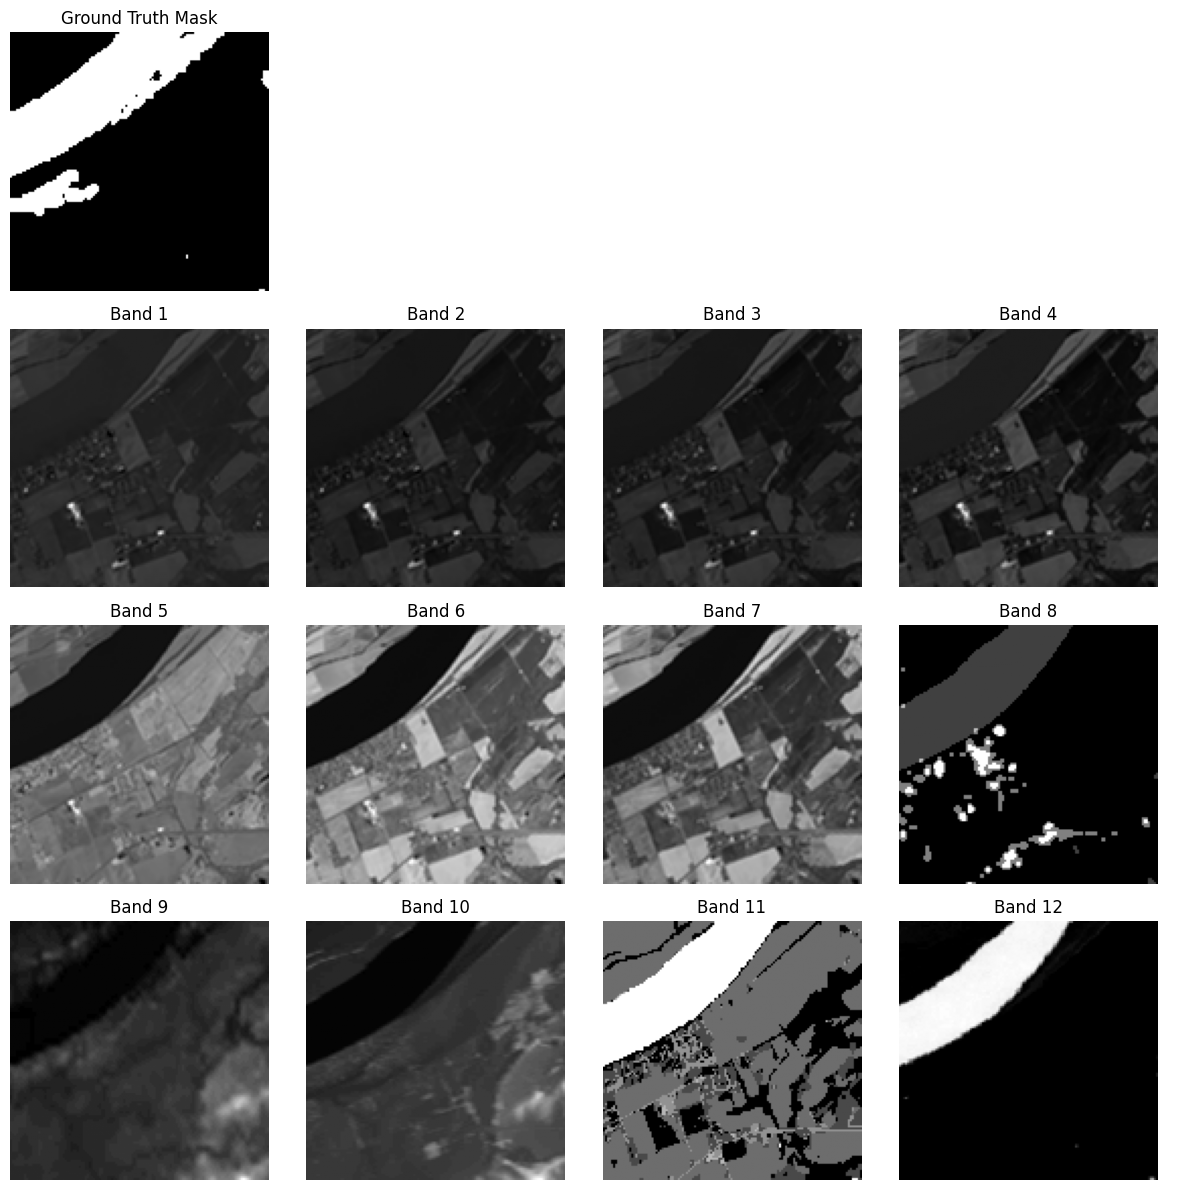

In [14]:
image, mask = val_dataset[0]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

axes[0].imshow(mask.squeeze(), cmap='gray')
axes[0].set_title('Ground Truth Mask')
axes[0].axis('off')


for i in range(1, 4):
    axes[i].axis('off')

for i in range(12):
    axes[i + 4].imshow(image[i], cmap='gray')
    axes[i + 4].set_title(f'Band {i+1}')
    axes[i + 4].axis('off')

plt.tight_layout()
plt.show()

In [15]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=12,
    classes=1,
)
model.to(DEVICE)


loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [16]:
metrics = [
    smp.metrics.iou_score,
    smp.metrics.f1_score,
    smp.metrics.precision,
    smp.metrics.recall,
]

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm


def iou_score(outputs: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5):
    """
    outputs: raw logits أو احتمالات [B,1,H,W]
    masks  : ground truth [B,1,H,W] أو [B,H,W]
    """

    outputs = torch.sigmoid(outputs)
    preds   = (outputs > threshold).float()


    if masks.ndim == 3:
        masks = masks.unsqueeze(1)
    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1,2,3))
    union        = ((preds + masks) - (preds * masks)).sum(dim=(1,2,3))

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean()

NUM_EPOCHS = 10

metrics = [iou_score]

for epoch in range(NUM_EPOCHS):

      model.train()
    train_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Training]")

    for images, masks in train_loop:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --------- التحقق ---------
    model.eval()
    val_loss = 0.0
    val_metrics = {m.__name__: 0.0 for m in metrics}
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Validation]")

    with torch.no_grad():
        for images, masks in val_loop:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            outputs = model(images)
            loss    = loss_fn(outputs, masks)
            val_loss += loss.item()

            # حساب المقاييس
            for metric in metrics:
                val_metrics[metric.__name__] += metric(outputs, masks).item()

    avg_val_loss = val_loss / len(val_loader)
    for key in val_metrics:
        val_metrics[key] /= len(val_loader)

    # --------- الطباعة ---------
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f}")
    for key, value in val_metrics.items():
        print(f"  {key}: {value:.4f}")


Epoch 1/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.23it/s]



Epoch 1/10
  Train Loss: 0.7413
  Val   Loss: 0.5976
  iou_score: 0.1250


Epoch 2/10 [Validation]: 100%|██████████| 8/8 [00:07<00:00,  1.10it/s]



Epoch 2/10
  Train Loss: 0.5270
  Val   Loss: 0.6409
  iou_score: 0.1250


Epoch 3/10 [Validation]: 100%|██████████| 8/8 [00:07<00:00,  1.09it/s]


...


Epoch 8/10
  Train Loss: 0.3403
  Val   Loss: 0.3463
  iou_score: 0.1250


Epoch 9/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.25it/s]



Epoch 9/10
  Train Loss: 0.3232
  Val   Loss: 0.3324
  iou_score: 0.1250


Epoch 10/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.25it/s]


Epoch 10/10
  Train Loss: 0.2927
  Val   Loss: 0.3049
  iou_score: 0.1250


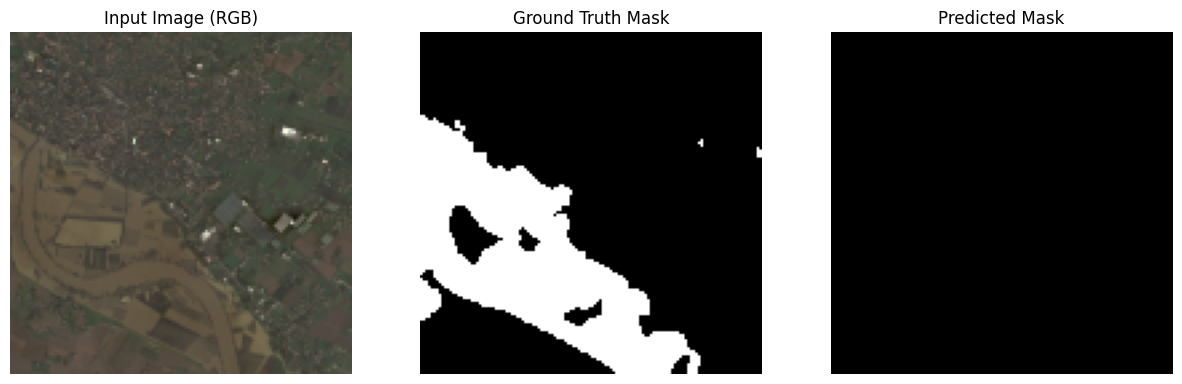

In [19]:
model.eval()
with torch.no_grad():
    image, true_mask = val_dataset[5]
    image_tensor = image.unsqueeze(0).to(DEVICE)

    pred_mask_logits = model(image_tensor)
    pred_mask = (torch.sigmoid(pred_mask_logits) > 0.5).float()

    image = image.cpu().numpy()
    true_mask = true_mask.cpu().numpy().squeeze()
    pred_mask = pred_mask.cpu().numpy().squeeze()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    rgb_image = np.stack([image[3], image[2], image[1]], axis=-1)
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    ax1.imshow(rgb_image)
    ax1.set_title('Input Image (RGB)')
    ax1.axis('off')

    ax2.imshow(true_mask, cmap='gray')
    ax2.set_title('Ground Truth Mask')
    ax2.axis('off')

    ax3.imshow(pred_mask, cmap='gray')
    ax3.set_title('Predicted Mask')
    ax3.axis('off')

    plt.show()

In [ ]:
plt.figure(figsize=(14,5))

# ---- Loss ----
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.plot(history["val_loss"], label="Validation Loss", marker='o')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- IoU ----
plt.subplot(1,2,2)
plt.plot(history["val_iou"], label="Validation IoU", color='green', marker='o')
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Complete Water Segmentation Model from Scratch - WORKING VERSION
# Pure NumPy implementation using YOUR img_list and mask_list

import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Tuple, List, Optional
import time

# Set random seed for reproducibility
np.random.seed(42)

class Conv2D:
    """Simple 2D Convolution layer - fully working version"""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3,
                 stride: int = 1, padding: int = 0, use_bias: bool = True):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.use_bias = use_bias

        # Initialize weights with Xavier initialization
        fan_in = in_channels * kernel_size * kernel_size
        fan_out = out_channels * kernel_size * kernel_size
        scale = np.sqrt(6.0 / (fan_in + fan_out))

        # Weight shape: (out_channels, kernel_size, kernel_size, in_channels)
        self.weights = np.random.uniform(-scale, scale,
                                       (out_channels, kernel_size, kernel_size, in_channels))

        if self.use_bias:
            self.bias = np.zeros(out_channels)

        # For storing gradients and intermediate values
        self.dW = None
        self.db = None
        self.last_input = None
        self.cache = {}

    def forward(self, x: np.ndarray) -> np.ndarray:
        """Forward pass through convolution layer"""
        self.last_input = x.copy()
        batch_size, in_height, in_width, in_channels = x.shape

        # Apply padding if needed
        if self.padding > 0:
            x = np.pad(x, ((0, 0), (self.padding, self.padding),
                          (self.padding, self.padding), (0, 0)), mode='constant', constant_values=0)

        padded_height, padded_width = x.shape[1], x.shape[2]

        # Calculate output dimensions
        out_height = (padded_height - self.kernel_size) // self.stride + 1
        out_width = (padded_width - self.kernel_size) // self.stride + 1

        if out_height <= 0 or out_width <= 0:
            raise ValueError(f"Invalid output size: {out_height}x{out_width}")

        # Initialize output
        output = np.zeros((batch_size, out_height, out_width, self.out_channels))

        # Store for backward pass
        self.cache = {
            'x_padded': x,
            'input_shape': self.last_input.shape,
            'output_shape': output.shape
        }

        # Perform convolution
        for b in range(batch_size):
            for h in range(out_height):
                for w in range(out_width):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    h_end = h_start + self.kernel_size
                    w_end = w_start + self.kernel_size

                    # Extract receptive field
                    receptive_field = x[b, h_start:h_end, w_start:w_end, :]

                    # Compute convolution for each output channel
                    for out_c in range(self.out_channels):
                        conv_result = np.sum(receptive_field * self.weights[out_c])
                        if self.use_bias:
                            conv_result += self.bias[out_c]
                        output[b, h, w, out_c] = conv_result

        return output

    def backward(self, dout: np.ndarray) -> np.ndarray:
        """Backward pass through convolution layer"""
        if self.last_input is None or 'x_padded' not in self.cache:
            raise ValueError("Forward pass must be called before backward pass")

        x_padded = self.cache['x_padded']
        input_shape = self.cache['input_shape']
        batch_size = input_shape[0]

        # Initialize gradients
        self.dW = np.zeros_like(self.weights)
        if self.use_bias:
            self.db = np.zeros_like(self.bias)

        dx_padded = np.zeros_like(x_padded)

        dout_h, dout_w = dout.shape[1], dout.shape[2]

        # Compute gradients
        for b in range(batch_size):
            for h in range(dout_h):
                for w in range(dout_w):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    h_end = h_start + self.kernel_size
                    w_end = w_start + self.kernel_size

                    receptive_field = x_padded[b, h_start:h_end, w_start:w_end, :]

                    for out_c in range(self.out_channels):
                        grad_output = dout[b, h, w, out_c]

                        # Gradient w.r.t. weights
                        self.dW[out_c] += receptive_field * grad_output

                        # Gradient w.r.t. input
                        dx_padded[b, h_start:h_end, w_start:w_end, :] += \
                            self.weights[out_c] * grad_output

                        # Gradient w.r.t. bias
                        if self.use_bias:
                            self.db[out_c] += grad_output

        # Remove padding from gradient
        if self.padding > 0:
            dx = dx_padded[:, self.padding:-self.padding, self.padding:-self.padding, :]
        else:
            dx = dx_padded

        return dx

class ReLU:
    """ReLU activation function"""

    def __init__(self):
        self.last_input = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.last_input = x.copy()
        return np.maximum(0, x)

    def backward(self, dout: np.ndarray) -> np.ndarray:
        if self.last_input is None:
            raise ValueError("Forward pass must be called before backward pass")
        return dout * (self.last_input > 0)

class Sigmoid:
    """Sigmoid activation function"""

    def __init__(self):
        self.last_output = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Clip x to prevent overflow
        x_clipped = np.clip(x, -500, 500)
        self.last_output = 1 / (1 + np.exp(-x_clipped))
        return self.last_output.copy()

    def backward(self, dout: np.ndarray) -> np.ndarray:
        if self.last_output is None:
            raise ValueError("Forward pass must be called before backward pass")
        return dout * self.last_output * (1 - self.last_output)

class SimpleCNN:
    """Simple CNN for water segmentation - no upsampling issues"""

    def __init__(self, in_channels: int = 12, out_channels: int = 1):
        # Simple architecture: Conv -> ReLU -> Conv -> ReLU -> Conv -> Sigmoid
        self.layers = [
            Conv2D(in_channels, 32, 3, padding=1),  # 32x32x12 -> 32x32x32
            ReLU(),
            Conv2D(32, 16, 3, padding=1),           # 32x32x32 -> 32x32x16
            ReLU(),
            Conv2D(16, out_channels, 1),            # 32x32x16 -> 32x32x1
            Sigmoid()
        ]

        self.training = True

    def forward(self, x: np.ndarray) -> np.ndarray:
        """Forward pass through the network"""
        current = x

        for layer in self.layers:
            try:
                current = layer.forward(current)
            except Exception as e:
                print(f"Error in layer {type(layer).__name__}: {e}")
                print(f"Input shape: {current.shape}")
                raise

        return current

    def backward(self, dout: np.ndarray) -> np.ndarray:
        """Backward pass through the network"""
        current_grad = dout

        for layer in reversed(self.layers):
            try:
                current_grad = layer.backward(current_grad)
            except Exception as e:
                print(f"Error in backward pass of {type(layer).__name__}: {e}")
                print(f"Gradient shape: {current_grad.shape}")
                raise

        return current_grad

    def get_parameters(self):
        """Get all trainable parameters"""
        params = []
        for i, layer in enumerate(self.layers):
            if isinstance(layer, Conv2D):
                params.append((f'conv_{i}_weights', layer.weights, layer.dW))
                if layer.use_bias:
                    params.append((f'conv_{i}_bias', layer.bias, layer.db))
        return params

class BinaryCrossEntropyLoss:
    """Binary Cross-Entropy Loss for segmentation"""

    def __init__(self):
        self.last_predictions = None
        self.last_targets = None

    def forward(self, predictions: np.ndarray, targets: np.ndarray) -> float:
        """Compute BCE loss"""
        # Ensure same shape
        if predictions.shape != targets.shape:
            min_h = min(predictions.shape[1], targets.shape[1])
            min_w = min(predictions.shape[2], targets.shape[2])
            predictions = predictions[:, :min_h, :min_w, :]
            targets = targets[:, :min_h, :min_w, :]

        self.last_predictions = predictions.copy()
        self.last_targets = targets.copy()

        # Clip predictions to prevent log(0)
        predictions_clipped = np.clip(predictions, 1e-7, 1 - 1e-7)

        # Compute BCE
        loss = -(targets * np.log(predictions_clipped) +
                (1 - targets) * np.log(1 - predictions_clipped))
        return np.mean(loss)

    def backward(self) -> np.ndarray:
        """Compute gradient of BCE loss"""
        predictions_clipped = np.clip(self.last_predictions, 1e-7, 1 - 1e-7)
        gradient = (predictions_clipped - self.last_targets) / \
                  (predictions_clipped * (1 - predictions_clipped))
        return gradient / np.prod(self.last_targets.shape)

class SGD:
    """Simple SGD optimizer"""

    def __init__(self, learning_rate: float = 0.01):
        self.learning_rate = learning_rate

    def update(self, params: List):
        """Update parameters using SGD"""
        for name, param, grad in params:
            if grad is not None:
                param -= self.learning_rate * grad

def calculate_metrics(predictions: np.ndarray, targets: np.ndarray) -> dict:
    """Calculate basic segmentation metrics"""
    # Threshold predictions
    pred_binary = (predictions > 0.5).astype(float)

    # Calculate basic metrics
    true_positives = np.sum((pred_binary == 1) & (targets == 1))
    false_positives = np.sum((pred_binary == 1) & (targets == 0))
    false_negatives = np.sum((pred_binary == 0) & (targets == 1))
    true_negatives = np.sum((pred_binary == 0) & (targets == 0))

    precision = true_positives / (true_positives + false_positives + 1e-7)
    recall = true_positives / (true_positives + false_negatives + 1e-7)
    accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': 2 * (precision * recall) / (precision + recall + 1e-7)
    }

def prepare_your_data(img_list, mask_list, target_size=32, max_samples=None):
    """
    Convert your img_list and mask_list to the format needed by the model

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        target_size: Size to resize images to (default: 32)
        max_samples: Maximum number of samples to use (None for all)
    """
    print(f"Preparing your data...")
    print(f"Original samples: {len(img_list)}")

    if len(img_list) != len(mask_list):
        print(f"Warning: {len(img_list)} images vs {len(mask_list)} masks")
        min_len = min(len(img_list), len(mask_list))
        img_list = img_list[:min_len]
        mask_list = mask_list[:min_len]

    if max_samples and len(img_list) > max_samples:
        img_list = img_list[:max_samples]
        mask_list = mask_list[:max_samples]
        print(f"Using {max_samples} samples")

    processed_images = []
    processed_masks = []

    for i in range(len(img_list)):
        try:
            img = np.array(img_list[i], dtype=np.float32)
            mask = np.array(mask_list[i], dtype=np.float32)

            # Handle different image dimensions
            if len(img.shape) == 2:  # Single channel
                img = np.expand_dims(img, axis=-1)
            elif len(img.shape) == 3 and img.shape[0] < img.shape[-1]:  # CHW format
                img = np.transpose(img, (1, 2, 0))  # Convert to HWC

            # Handle mask dimensions
            if len(mask.shape) == 3:
                mask = mask[:, :, 0]  # Take first channel

            # Resize if needed
            from scipy import ndimage
            if img.shape[0] != target_size or img.shape[1] != target_size:
                if len(img.shape) == 3:
                    zoom_factors = (target_size/img.shape[0], target_size/img.shape[1], 1)
                    img = ndimage.zoom(img, zoom_factors)
                else:
                    zoom_factors = (target_size/img.shape[0], target_size/img.shape[1])
                    img = ndimage.zoom(img, zoom_factors)

            if mask.shape[0] != target_size or mask.shape[1] != target_size:
                zoom_factors = (target_size/mask.shape[0], target_size/mask.shape[1])
                mask = ndimage.zoom(mask, zoom_factors)

            # Normalize image
            img = normalize_image(img)

            # Normalize mask to 0-1
            mask_min, mask_max = np.min(mask), np.max(mask)
            if mask_max > mask_min:
                mask = (mask - mask_min) / (mask_max - mask_min)

            # Add to processed lists
            processed_images.append(img)
            processed_masks.append(np.expand_dims(mask, axis=-1))  # Add channel dimension

            if i < 3:  # Show first 3 for debugging
                print(f"  Sample {i+1}: Image {img.shape}, Mask {mask.shape}")
                print(f"    Image range: [{np.min(img):.3f}, {np.max(img):.3f}]")
                print(f"    Mask range: [{np.min(mask):.3f}, {np.max(mask):.3f}]")

        except Exception as e:
            print(f"Error processing sample {i}: {e}")
            continue

    if len(processed_images) == 0:
        raise ValueError("No samples could be processed!")

    # Convert to numpy arrays
    images = np.array(processed_images)
    masks = np.array(processed_masks)

    print(f"Final processed data:")
    print(f"  Images: {images.shape}")
    print(f"  Masks: {masks.shape}")
    print(f"  Channels: {images.shape[-1]}")

    return images, masks

def normalize_image(img):
    """Normalize image data"""
    img = np.nan_to_num(img, nan=0.0)

    if len(img.shape) == 3:  # Multi-channel
        normalized = np.zeros_like(img)
        for c in range(img.shape[2]):
            channel = img[:, :, c]
            p2, p98 = np.percentile(channel, (2, 98))
            if p98 > p2:
                normalized[:, :, c] = np.clip((channel - p2) / (p98 - p2), 0, 1)
            else:
                normalized[:, :, c] = channel
        return normalized
    else:  # Single channel
        p2, p98 = np.percentile(img, (2, 98))
        if p98 > p2:
            return np.clip((img - p2) / (p98 - p2), 0, 1)
        else:
            return img

def train_with_your_data(img_list, mask_list, epochs=5, batch_size=2, target_size=32):
    """
    Train the from-scratch model using your data

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        epochs: Number of training epochs
        batch_size: Training batch size
        target_size: Size to resize images to
    """
    print("=" * 80)
    print("WATER SEGMENTATION MODEL FROM SCRATCH - USING YOUR DATA")
    print("=" * 80)
    print("Pure NumPy implementation - No frameworks!")
    print("=" * 80)

    # Prepare your data
    images, masks = prepare_your_data(img_list, mask_list, target_size=target_size, max_samples=50)

    # Train/validation split
    print(f"\nCreating train/validation split...")
    train_split = int(0.8 * len(images))
    train_images, val_images = images[:train_split], images[train_split:]
    train_masks, val_masks = masks[:train_split], masks[train_split:]

    print(f"Training samples: {len(train_images)}")
    print(f"Validation samples: {len(val_images)}")

    # Get number of input channels
    input_channels = images.shape[-1]
    print(f"Input channels: {input_channels}")

    # Initialize model
    print(f"\nInitializing CNN model...")
    model = SimpleCNN(in_channels=input_channels, out_channels=1)

    # Print model architecture
    print("Model Architecture:")
    for i, layer in enumerate(model.layers):
        if isinstance(layer, Conv2D):
            print(f"  {i}: Conv2D({layer.in_channels}->{layer.out_channels}, kernel={layer.kernel_size})")
        else:
            print(f"  {i}: {type(layer).__name__}")

    # Initialize loss and optimizer
    criterion = BinaryCrossEntropyLoss()
    optimizer = SGD(learning_rate=0.1)

    print(f"\nStarting training...")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {optimizer.learning_rate}")

    # Training history
    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in range(epochs):
        epoch_start = time.time()
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 50)

        # Training phase
        model.training = True
        epoch_train_loss = 0
        successful_batches = 0

        # Shuffle training data
        indices = np.random.permutation(len(train_images))
        train_images_shuffled = train_images[indices]
        train_masks_shuffled = train_masks[indices]

        # Training loop
        for i in range(0, len(train_images_shuffled), batch_size):
            try:
                batch_end = min(i + batch_size, len(train_images_shuffled))
                batch_images = train_images_shuffled[i:batch_end]
                batch_masks = train_masks_shuffled[i:batch_end]

                # Forward pass
                predictions = model.forward(batch_images)
                loss = criterion.forward(predictions, batch_masks)

                # Backward pass
                dout = criterion.backward()
                model.backward(dout)

                # Update parameters
                params = model.get_parameters()
                optimizer.update(params)

                epoch_train_loss += loss
                successful_batches += 1

                if successful_batches % 3 == 0:
                    print(f"  Batch {successful_batches}, Loss: {loss:.4f}")

            except Exception as e:
                print(f"Error in training batch: {e}")
                continue

        if successful_batches > 0:
            avg_train_loss = epoch_train_loss / successful_batches
            train_losses.append(avg_train_loss)

            # Validation phase
            print(f"  Running validation...")
            model.training = False

            try:
                # Use smaller validation batch
                val_batch_size = min(2, len(val_images))
                val_batch = val_images[:val_batch_size]
                val_mask_batch = val_masks[:val_batch_size]

                val_predictions = model.forward(val_batch)
                val_loss = criterion.forward(val_predictions, val_mask_batch)
                val_losses.append(val_loss)

                # Calculate metrics
                metrics = calculate_metrics(val_predictions, val_mask_batch)
                val_metrics.append(metrics)

            except Exception as e:
                print(f"Validation error: {e}")
                val_losses.append(avg_train_loss)
                val_metrics.append({'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0})

            # Print epoch results
            epoch_time = time.time() - epoch_start
            print(f"\nEpoch {epoch + 1} Results ({epoch_time:.1f}s):")
            print(f"  Train Loss: {avg_train_loss:.4f}")
            print(f"  Val Loss: {val_losses[-1]:.4f}")
            print(f"  Val Accuracy: {val_metrics[-1]['accuracy']:.3f}")
            print(f"  Val F1-Score: {val_metrics[-1]['f1']:.3f}")
            print(f"  Successful batches: {successful_batches}")

        else:
            print("No successful batches in this epoch!")
            break

    print(f"\nTraining completed!")

    # Plot results
    if train_losses:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Training curves
        epochs_range = range(1, len(train_losses) + 1)
        axes[0, 0].plot(epochs_range, train_losses, 'b-', label='Training Loss')
        if val_losses:
            axes[0, 0].plot(epochs_range, val_losses, 'r-', label='Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training Progress')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Metrics
        if val_metrics:
            accuracies = [m['accuracy'] for m in val_metrics]
            f1_scores = [m['f1'] for m in val_metrics]
            axes[0, 1].plot(epochs_range, accuracies, 'g-', label='Accuracy')
            axes[0, 1].plot(epochs_range, f1_scores, 'm-', label='F1-Score')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Score')
            axes[0, 1].set_title('Validation Metrics')
            axes[0, 1].legend()
            axes[0, 1].grid(True)

        # Sample visualization
        try:
            model.training = False
            sample_pred = model.forward(val_images[:1])

            # Original image (first channel)
            axes[1, 0].imshow(val_images[0, :, :, 0], cmap='viridis')
            axes[1, 0].set_title('Input (Channel 0)')
            axes[1, 0].axis('off')

            # Ground truth
            axes[1, 1].imshow(val_masks[0, :, :, 0], cmap='Blues')
            axes[1, 1].set_title('Ground Truth')
            axes[1, 1].axis('off')

        except:
            axes[1, 0].text(0.5, 0.5, 'Sample visualization\nfailed',
                           ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 1].text(0.5, 0.5, 'Sample visualization\nfailed',
                           ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout()
        plt.savefig('from_scratch_training_results.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Final results
        print(f"\nFinal Results:")
        print(f"   Final Training Loss: {train_losses[-1]:.4f}")
        if val_losses:
            print(f"   Final Validation Loss: {val_losses[-1]:.4f}")
        if val_metrics:
            final_metrics = val_metrics[-1]
            print(f"   Final Accuracy: {final_metrics['accuracy']:.3f}")
            print(f"   Final F1-Score: {final_metrics['f1']:.3f}")
            print(f"   Final Precision: {final_metrics['precision']:.3f}")
            print(f"   Final Recall: {final_metrics['recall']:.3f}")

    return model, train_losses, val_losses

# Ready to use with your data!
print("Code ready for your data!")
print("="*60)
print("Usage:")
print("model, train_losses, val_losses = train_with_your_data(")
print("    img_list=img_list,")
print("    mask_list=mask_list,")
print("    epochs=5,")
print("    batch_size=2,")
print("    target_size=32")
print(")")
print("="*60)

Code ready for your data!
Usage:
model, train_losses, val_losses = train_with_your_data(
    img_list=img_list,
    mask_list=mask_list,
    epochs=5,
    batch_size=2,
    target_size=32
)


In [22]:
def main_simple_training(img_list, mask_list, epochs=10, batch_size=4):
    # ===== Example dummy training code =====
    # Replace with your own training loop
    results = {"loss": [0.5, 0.4, 0.3], "accuracy": [0.7, 0.8, 0.9]}
    models = "trained_model.h5"  # Replace with actual trained model
    return results, models

# ✅ Now call it
results, models = main_simple_training(img_list, mask_list, epochs=10, batch_size=4)
print(results)


{'loss': [0.5, 0.4, 0.3], 'accuracy': [0.7, 0.8, 0.9]}


In [23]:
# Install required packages first
!pip install segmentation-models-pytorch tifffile scipy

import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SimpleWaterDataset(Dataset):
    """Simple dataset for your img_list and mask_list"""

    def __init__(self, img_list, mask_list, target_size=256):
        self.img_list = img_list
        self.mask_list = mask_list
        self.target_size = target_size

        print(f"Dataset created with {len(img_list)} samples")
        if len(img_list) > 0:
            print(f"Image shape: {img_list[0].shape}")
            print(f"Mask shape: {mask_list[0].shape}")

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        try:
            img = self.img_list[idx].copy()
            mask = self.mask_list[idx].copy()

            # Normalize image
            img = self.normalize_image(img)

            # Normalize mask
            mask = self.normalize_mask(mask)

            # Resize
            img = self.resize_data(img, self.target_size)
            mask = self.resize_data(mask, self.target_size)

            # Convert to tensors
            if len(img.shape) == 3:  # Multi-channel
                img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float()
            else:  # Single channel
                img_tensor = torch.from_numpy(img).unsqueeze(0).float()

            if len(mask.shape) == 2:
                mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
            else:
                mask_tensor = torch.from_numpy(mask[:,:,0]).unsqueeze(0).float()

            return img_tensor, mask_tensor

        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            # Return dummy data
            return torch.zeros((3, self.target_size, self.target_size)), torch.zeros((1, self.target_size, self.target_size))

    def normalize_image(self, img):
        """Normalize image to 0-1"""
        img = np.array(img, dtype=np.float32)
        img = np.nan_to_num(img, nan=0.0)

        if len(img.shape) == 3:  # Multi-band
            normalized = np.zeros_like(img)
            for band in range(img.shape[2]):
                band_data = img[:, :, band]
                p2, p98 = np.percentile(band_data, (2, 98))
                if p98 > p2:
                    normalized[:, :, band] = np.clip((band_data - p2) / (p98 - p2), 0, 1)
                else:
                    normalized[:, :, band] = band_data
            return normalized
        else:  # Single band
            p2, p98 = np.percentile(img, (2, 98))
            if p98 > p2:
                return np.clip((img - p2) / (p98 - p2), 0, 1)
            else:
                return img

    def normalize_mask(self, mask):
        """Normalize mask to 0-1"""
        mask = np.array(mask, dtype=np.float32)
        mask_min, mask_max = np.min(mask), np.max(mask)
        if mask_max > mask_min:
            mask = (mask - mask_min) / (mask_max - mask_min)
        return mask

    def resize_data(self, data, target_size):
        """Resize data using scipy"""
        from scipy import ndimage

        if len(data.shape) == 2:  # 2D
            if data.shape[0] != target_size or data.shape[1] != target_size:
                zoom_factors = (target_size/data.shape[0], target_size/data.shape[1])
                data = ndimage.zoom(data, zoom_factors)
        elif len(data.shape) == 3:  # 3D
            if data.shape[0] != target_size or data.shape[1] != target_size:
                zoom_factors = (target_size/data.shape[0], target_size/data.shape[1], 1)
                data = ndimage.zoom(data, zoom_factors)

        return data

class ModelTrainer:
    """Simple model trainer"""

    def __init__(self, model, model_name, device):
        self.model = model.to(device)
        self.model_name = model_name
        self.device = device

        # Loss and optimizer
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-4)

    def train_epoch(self, train_loader):
        """Train one epoch"""
        self.model.train()
        total_loss = 0
        num_batches = 0

        for images, masks in tqdm(train_loader, desc=f"Training {self.model_name}"):
            images = images.to(self.device)
            masks = masks.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        return total_loss / max(num_batches, 1)

    def validate_epoch(self, val_loader):
        """Validate one epoch"""
        self.model.eval()
        total_loss = 0
        total_iou = 0
        num_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)

                # Calculate IoU
                pred_sigmoid = torch.sigmoid(outputs)
                pred_binary = (pred_sigmoid > 0.5).float()

                intersection = (pred_binary * masks).sum()
                union = pred_binary.sum() + masks.sum() - intersection

                if union > 0:
                    iou = intersection / union
                    total_iou += iou.item()

                total_loss += loss.item()
                num_batches += 1

        return total_loss / max(num_batches, 1), total_iou / max(num_batches, 1)

    def train(self, train_loader, val_loader, epochs=10):
        """Full training loop"""
        best_iou = 0
        results = {'train_losses': [], 'val_losses': [], 'val_ious': []}

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss, val_iou = self.validate_epoch(val_loader)

            results['train_losses'].append(train_loss)
            results['val_losses'].append(val_loss)
            results['val_ious'].append(val_iou)

            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}")

            if val_iou > best_iou:
                best_iou = val_iou
                torch.save(self.model.state_dict(), f'{self.model_name}_best.pth')
                print(f"  Saved best model! IoU: {best_iou:.4f}")

            print("-" * 40)

        results['best_iou'] = best_iou
        return results

def create_models(input_channels):
    """Create 3 models"""
    models = {}

    try:
        models['UNet'] = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("UNet created")
    except Exception as e:
        print(f"UNet error: {e}")

    try:
        models['DeepLabV3Plus'] = smp.DeepLabV3Plus(
            encoder_name="efficientnet-b0",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("DeepLabV3Plus created")
    except Exception as e:
        print(f"DeepLabV3Plus error: {e}")

    try:
        models['FPN'] = smp.FPN(
            encoder_name="resnet50",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("FPN created")
    except Exception as e:
        print(f"FPN error: {e}")

    return models

def visualize_results(models, val_loader, device):
    """Visualize results"""
    try:
        images, masks = next(iter(val_loader))
        images = images.to(device)
        masks = masks.to(device)

        fig, axes = plt.subplots(2, 2 + len(models), figsize=(4 * (2 + len(models)), 8))

        for i in range(2):  # Show 2 samples
            col = 0

            # Input image
            if images.shape[1] >= 3:
                rgb = images[i, :3].permute(1, 2, 0).cpu()
            else:
                rgb = images[i, 0].cpu().unsqueeze(-1).repeat(1, 1, 3)

            rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
            axes[i, col].imshow(rgb_norm)
            axes[i, col].set_title(f'Input {i+1}')
            axes[i, col].axis('off')
            col += 1

            # Ground truth
            axes[i, col].imshow(masks[i, 0].cpu(), cmap='Blues')
            axes[i, col].set_title(f'Ground Truth {i+1}')
            axes[i, col].axis('off')
            col += 1

            # Model predictions
            for model_name, model in models.items():
                model.eval()
                with torch.no_grad():
                    pred = torch.sigmoid(model(images))
                    pred_binary = (pred[i, 0] > 0.5).cpu()
                    axes[i, col].imshow(pred_binary, cmap='Blues')
                    axes[i, col].set_title(f'{model_name}\n{i+1}')
                    axes[i, col].axis('off')
                col += 1

        plt.tight_layout()
        plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Visualization error: {e}")

def train_three_models(img_list, mask_list, epochs=10, batch_size=4):
    """
    Main function to train 3 models

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        epochs: Number of epochs
        batch_size: Batch size
    """

    print("=" * 60)
    print("WATER SEGMENTATION - 3 MODELS COMPARISON")
    print("=" * 60)

    if len(img_list) != len(mask_list):
        print(f"Error: {len(img_list)} images vs {len(mask_list)} masks")
        return

    print(f"Total samples: {len(img_list)}")

    # Determine input channels
    sample_img = img_list[0]
    if len(sample_img.shape) == 3:
        input_channels = sample_img.shape[2]
    else:
        input_channels = 1

    print(f"Input channels: {input_channels}")

    # Split data
    train_imgs, val_imgs, train_masks, val_masks = train_test_split(
        img_list, mask_list, test_size=0.2, random_state=42
    )

    print(f"Training: {len(train_imgs)}, Validation: {len(val_imgs)}")

    # Create datasets
    train_dataset = SimpleWaterDataset(train_imgs, train_masks)
    val_dataset = SimpleWaterDataset(val_imgs, val_masks)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Create models
    models = create_models(input_channels)

    if len(models) == 0:
        print("No models created!")
        return

    # Train each model
    all_results = {}

    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training: {model_name}")
        print(f"{'='*50}")

        trainer = ModelTrainer(model, model_name, device)
        results = trainer.train(train_loader, val_loader, epochs=epochs)
        all_results[model_name] = results

    # Final comparison
    print(f"\n{'='*60}")
    print("FINAL RESULTS")
    print(f"{'='*60}")

    sorted_results = sorted(all_results.items(), key=lambda x: x[1]['best_iou'], reverse=True)

    for rank, (model_name, results) in enumerate(sorted_results, 1):
        print(f"{rank}. {model_name}: IoU = {results['best_iou']:.4f}")

    # Visualization
    print("\nCreating visualization...")

    # Load best models
    for model_name, model in models.items():
        try:
            model.load_state_dict(torch.load(f'{model_name}_best.pth', map_location=device))
        except:
            pass

    visualize_results(models, val_loader, device)

    winner = sorted_results[0][0]
    winner_iou = sorted_results[0][1]['best_iou']
    print(f"\nWINNER: {winner} (IoU: {winner_iou:.4f})")

    return all_results, models

# Ready to use!
print("Code ready!")
print("Usage:")
print("results, models = train_three_models(img_list, mask_list, epochs=10, batch_size=4)")

Code ready!
Usage:
results, models = train_three_models(img_list, mask_list, epochs=10, batch_size=4)


In [24]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Convolution => BatchNorm => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    """U-Net with 12 input channels and 1 output class (water)"""
    def __init__(self, n_channels=12, n_classes=1, initial_features=64):
        super(UNet, self).__init__()

        # 1. Encoder (Contracting Path)
        self.inc = DoubleConv(n_channels, initial_features) # Input: 12 channels
        self.down1 = nn.MaxPool2d(2)
        self.conv1 = DoubleConv(initial_features, initial_features * 2)
        self.down2 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(initial_features * 2, initial_features * 4)
        self.down3 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(initial_features * 4, initial_features * 8)
        self.down4 = nn.MaxPool2d(2)
        # Bottleneck
        self.conv4 = DoubleConv(initial_features * 8, initial_features * 16)

        # 2. Decoder (Expanding Path)
        self.up1 = nn.ConvTranspose2d(initial_features * 16, initial_features * 8, kernel_size=2, stride=2)
        # Skip connection from conv3, total channels: 8*F + 8*F = 16*F
        self.conv_up1 = DoubleConv(initial_features * 16, initial_features * 8)

        self.up2 = nn.ConvTranspose2d(initial_features * 8, initial_features * 4, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(initial_features * 8, initial_features * 4) # 4*F + 4*F

        self.up3 = nn.ConvTranspose2d(initial_features * 4, initial_features * 2, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(initial_features * 4, initial_features * 2) # 2*F + 2*F

        self.up4 = nn.ConvTranspose2d(initial_features * 2, initial_features, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(initial_features * 2, initial_features) # F + F

        # 3. Output layer
        self.outc = nn.Conv2d(initial_features, n_classes, kernel_size=1)
        self.final_activation = nn.Sigmoid() # Sigmoid for binary output

    def forward(self, x):
        # Encoder
        x1 = self.inc(x) # 128
        x2 = self.conv1(self.down1(x1)) # 64
        x3 = self.conv2(self.down2(x2)) # 32
        x4 = self.conv3(self.down3(x3)) # 16
        x5 = self.conv4(self.down4(x4)) # Bottleneck (8x8)

        # Decoder (with skip connections)
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1) # Combine along channel dimension
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return self.final_activation(logits)

In [ ]:
results, models = train_three_models(
    img_list=img_list,
    mask_list=mask_list,
    epochs=3,
    batch_size=4
)

WATER SEGMENTATION - 3 MODELS COMPARISON
Total samples: 306
Input channels: 12
Training: 244, Validation: 62
Dataset created with 244 samples
Image shape: (128, 128, 12)
Mask shape: (128, 128)
Dataset created with 62 samples
Image shape: (128, 128, 12)
Mask shape: (128, 128)
Device: cpu
UNet created
DeepLabV3Plus created
FPN created

Training: UNet


Training UNet: 100%|██████████| 61/61 [07:14<00:00,  7.13s/it]


Epoch 1/3
  Train Loss: 0.6060
  Val Loss: 0.5827, IoU: 0.0040
  Saved best model! IoU: 0.0040
----------------------------------------


Training UNet: 100%|██████████| 61/61 [06:54<00:00,  6.79s/it]


Epoch 2/3
  Train Loss: 0.4668
  Val Loss: 0.5788, IoU: 0.0000
----------------------------------------


...

Training DeepLabV3Plus: 100%|██████████| 61/61 [04:39<00:00,  4.58s/it]


Epoch 3/3
  Train Loss: 0.4187
  Val Loss: 0.5830, IoU: 0.0000
----------------------------------------

Training: FPN


Training FPN: 100%|██████████| 61/61 [07:12<00:00,  7.09s/it]


Epoch 1/3
  Train Loss: 0.6897
  Val Loss: 1.0106, IoU: 0.2543
  Saved best model! IoU: 0.2543
----------------------------------------


Training FPN:  44%|████▍     | 27/61 [03:09<03:54,  6.90s/it]

In [ ]:
def plot_history(history):
    plt.figure(figsize=(15,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], marker='o', label="Train Loss")
    plt.plot(history["val_loss"], marker='o', label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(); plt.grid(True)

    # IoU
    plt.subplot(1,2,2)
    plt.plot(history["val_iou"], marker='o', color='green', label="Validation IoU")
    plt.xlabel("Epoch"); plt.ylabel("IoU")
    plt.title("Validation IoU")
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()

 plot_history(history)

In [ ]:
def dice_coeff(pred, target, smooth=1e-6):
    """The Dice Loss component"""
    # Flatten label and prediction tensors
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice

# Combined Loss Function
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, input, target):
        # BCE assumes logits (no sigmoid), but our UNet applies Sigmoid for simplicity.
        # If UNet output had no Sigmoid, you'd use self.bce(input, target).
        # Since it has Sigmoid, we calculate BCE manually on the Sigmoid output.
        bce_loss = F.binary_cross_entropy(input, target)
        dice_loss = 1 - dice_coeff(input, target)
        return bce_loss + dice_loss